In [ ]:
# import zipfile

# zip_ref = zipfile.ZipFile("/content/Cats_Dogs.zip", 'r')
# zip_ref.extractall("content/")
# zip_ref.close()

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
## TO split the data
## Need to run only once as after the splited datsaset is already present on your drive

import os
import shutil
import random

# 1. Paths
original_base_dir = "/content/gdrive/MyDrive/Cats_Dogs"        # your existing folder
new_base_dir = "/content/gdrive/MyDrive/Cats_Dogs_split"       # new folder to create

classes = ["cats", "dogs"]             # class names (must match folder names)
train_ratio = 0.8                      # 80% train, 20% test

# 2. Create train/test folders for each class
for split in ["train", "test"]:
    for cls in classes:
        split_dir = os.path.join(new_base_dir, split, cls)
        os.makedirs(split_dir, exist_ok=True)

# 3. For each class, split images into train and test
for cls in classes:
    class_dir = os.path.join(original_base_dir, cls)
    images = os.listdir(class_dir)

    # filter only image files (optional but safer)
    images = [img for img in images if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

    random.shuffle(images)  # shuffle for randomness

    train_count = int(len(images) * train_ratio)
    train_images = images[:train_count]
    test_images = images[train_count:]

    print(f"{cls}: {len(train_images)} train, {len(test_images)} test")

    # 4. Copy train images
    for img in train_images:
        src = os.path.join(class_dir, img)
        dst = os.path.join(new_base_dir, "train", cls, img)
        shutil.copy2(src, dst)

    # 5. Copy test images
    for img in test_images:
        src = os.path.join(class_dir, img)
        dst = os.path.join(new_base_dir, "test", cls, img)
        shutil.copy2(src, dst)

OSError: [Errno 107] Transport endpoint is not connected: '/content/gdrive/MyDrive'

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models,callbacks
from keras.models import Sequential

In [3]:
from keras.preprocessing import image
train_ds = keras.utils.image_dataset_from_directory(
    directory="/content/drive/MyDrive/Cats_Dogs_split/train",
    labels="inferred",
    label_mode="int",
    image_size=(256,256),
    batch_size=32
)

test_ds=keras.utils.image_dataset_from_directory(
    directory="/content/drive/MyDrive/Cats_Dogs_split/test",
    labels="inferred",
    label_mode="int",
    image_size=(256,256),
    batch_size=32
)

Found 1600 files belonging to 2 classes.
Found 400 files belonging to 2 classes.


In [5]:
#normalization
def process(image,labels):
  image=tf.cast(image/255.0,tf.float32)
  return image,labels

train_ds=train_ds.map(process)
test_ds=test_ds.map(process)

In [6]:
from keras import layers
data_augumentation=tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [7]:
def create_model():
  model=models.Sequential([
      data_augumentation,

      layers.Conv2D(32,(3,3),activation='relu',input_shape=(256,256,3)),
      layers.BatchNormalization(),
      layers.MaxPooling2D((2,2)),

      layers.Conv2D(64,(3,3),activation='relu'),
      layers.BatchNormalization(),
      layers.MaxPooling2D((2,2)),

      layers.Conv2D(128,(3,3),activation='relu'),
      layers.BatchNormalization(),
      layers.MaxPooling2D((2,2)),

      layers.Flatten(),

      layers.Dense(128,activation='relu'),
      layers.Dense(64,activation='relu'),
      layers.Dropout(0.5),
      layers.Dense(1,activation='sigmoid')
  ])
  return model


In [8]:
model=create_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [11]:
history=model.fit(train_ds,epochs=10,validation_data=test_ds,batch_size=32)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 521s 10s/step - accuracy: 0.5457 - loss: 7.2688 - val_accuracy: 0.5100 - val_loss: 4.0339
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 416s 8s/step - accuracy: 0.5223 - loss: 2.0771 - val_accuracy: 0.4750 - val_loss: 3.1844
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 430s 8s/step - accuracy: 0.5310 - loss: 0.8452 - val_accuracy: 0.5100 - val_loss: 2.4496
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 417s 8s/step - accuracy: 0.5507 - loss: 0.7066 - val_accuracy: 0.5050 - val_loss: 2.9983
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 403s 8s/step - accuracy: 0.6204 - loss: 0.6571 - val_accuracy: 0.5075 - val_loss: 2.3738
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 404s 8s/step - accuracy: 0.6232 - loss: 0.6370 - val_accuracy: 0.5400 - val_loss: 1.4387
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 459s 8s/step - accuracy: 0.6383 - loss: 0.6682 - val_accuracy: 0.5525 - val_loss: 0.8501
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 420s 8s/step - accuracy: 0.6222 - loss: 0.6474 - val_accuracy: 0.5800 - 

In [13]:
import matplotlib.pyplot as plt

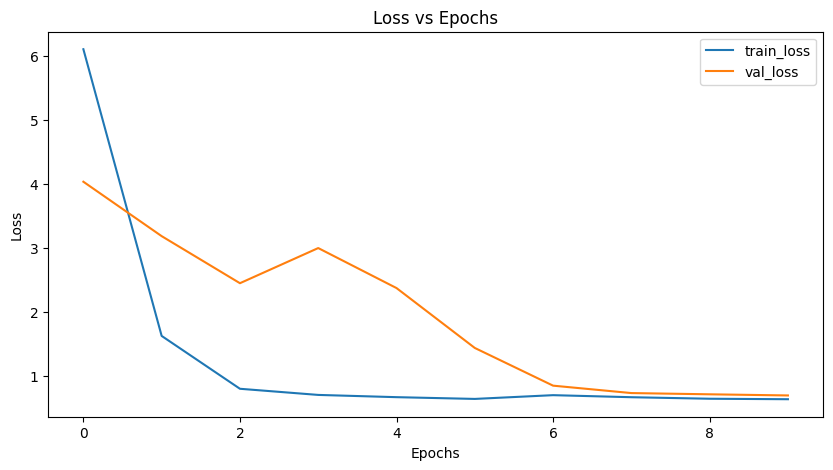

In [14]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.show()

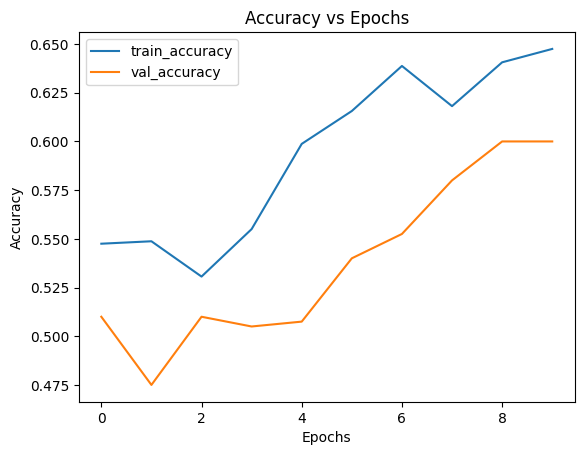

In [15]:
plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.show()